In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

#1. import database / data


In [3]:
conn = sqlite3.connect('customer_churn.db')

sql_query = """
    SELECT name
    FROM sqlite_master
    WHERE type='table';
"""

tables = pd.read_sql(sql_query, conn)

# create dataframe for each table
for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created dataframe: df_{table_name}")

# Close connection ONLY after the loop is completely done
conn.close()

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [4]:
# Print table names and column names
conn = sqlite3.connect('customer_churn.db')

for table_name in tables['name']:
    print(f"\nTable Name: {table_name}")
    # Get column information
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query, conn)
    print("Columns:")
    print(columns['name'].tolist())

# Close connection
conn.close()


Table Name: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [5]:
# a. rename col - name
df_db_customer.rename(columns = {'name' : 'customer_name'}, inplace= True)

In [6]:
df_db_customer.head()

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [7]:
# 1. Standardize text and clean columns in db_customer
df_db_customer.rename(columns={'name': 'customer_name'}, inplace=True)
df_db_customer['interests'] = df_db_customer['interests'].fillna('Unknown')

# 2. Convert raw string dates to official pandas datetime objects
df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'], errors='coerce')
df_db_subscription['subscription_start_date'] = pd.to_datetime(df_db_subscription['subscription_start_date'], errors='coerce')
df_db_subscription['cancellation_date'] = pd.to_datetime(df_db_subscription['cancellation_date'], errors='coerce')

# 3. Create a clean Binary Churn Column (1 if cancelled, 0 if active)
df_db_subscription['is_churned'] = df_db_subscription['cancellation_date'].notna().astype(int)

# 4. Feature Engineering: Calculate precise age
current_year = 2026
df_db_customer['age'] = current_year - df_db_customer['dob'].dt.year

print("Data Cleaning Completed!")

Data Cleaning Completed!


In [8]:
# Merge customer demographics with subscription metrics
df_analysis = pd.merge(df_db_customer, df_db_subscription, on='customerid', how='inner')

print(f"Merged Dataset Ready! Rows: {df_analysis.shape[0]}, Columns: {df_analysis.shape[1]}")
df_analysis[['customerid', 'customer_name', 'subscription_type', 'is_churned', 'monthly_charges']].head()

Merged Dataset Ready! Rows: 21, Columns: 20


,customerid,customer_name,subscription_type,is_churned,monthly_charges
0,0002-ORFBO,keshav,Refferal,0,13.99
1,0003-MKNFE,raghav,Paid,1,12.99
2,0004-TLHLJ,lalita,Organic,0,6.99
3,0011-IGKFF,mohan,Paid,0,22.99
4,0013-EXCHZ,mira,Refferal,1,13.99


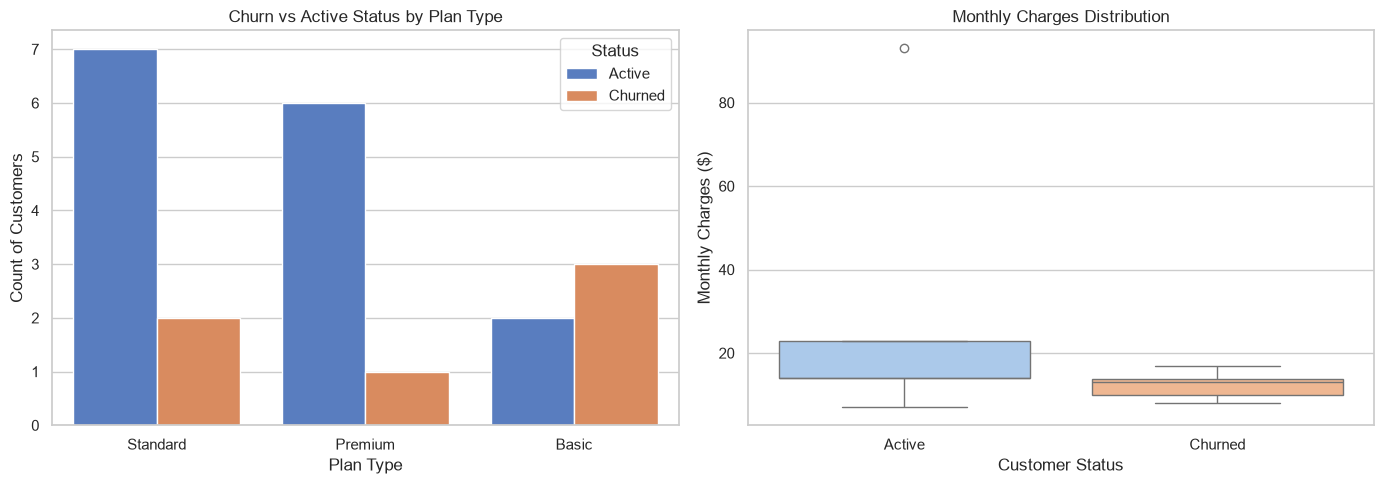

In [10]:
#Generate Insights & Visualizations

import matplotlib.pyplot as plt
import seaborn as sns

# Set portfolio design theme
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Churn Count by Plan Type
sns.countplot(
    data=df_analysis, 
    x='plan_type', 
    hue='is_churned', 
    ax=axes[0], 
    palette='muted'
)
axes[0].set_title('Churn vs Active Status by Plan Type')
axes[0].set_xlabel('Plan Type')
axes[0].set_ylabel('Count of Customers')
axes[0].legend(title='Status', labels=['Active', 'Churned'])

# Plot 2: Monthly Charges Distribution for Churned vs Active Users
sns.boxplot(
    data=df_analysis, 
    x='is_churned', 
    y='monthly_charges', 
    hue='is_churned',  # Fixes the palette warning
    legend=False,
    ax=axes[1], 
    palette='pastel'
)
axes[1].set_title('Monthly Charges Distribution')
axes[1].set_xlabel('Customer Status')
axes[1].set_xticks([0, 1])  # Fixes the ticklabels warning
axes[1].set_xticklabels(['Active', 'Churned'])
axes[1].set_ylabel('Monthly Charges ($)')

plt.tight_layout()
plt.show()

In [11]:
# Calculate absolute churn statistics
total_customers = len(df_analysis)
churned_customers = df_analysis['is_churned'].sum()
churn_rate = (churned_customers / total_customers) * 100

print(f"--- Key Portfolio Metrics ---")
print(f"Total Evaluated Customer Base: {total_customers}")
print(f"Total Churned Customers: {churned_customers}")
print(f"Overall Platform Churn Rate: {churn_rate:.2f}%")

--- Key Portfolio Metrics ---
Total Evaluated Customer Base: 21
Total Churned Customers: 6
Overall Platform Churn Rate: 28.57%
